# Chapter 8 (Economic Modeling) — IAMC/AR6 Scenario Databases

IPCC scenario-database ensemble exercises: SR1.5-consistent (IAMC15)
emissions-pathway spaghetti plots for three scenario sets with a 2050
net-zero marker, mean$\pm$CI bands for emissions and for
temperature/probability-of-exceeding-1.5$^\circ$C paths, and AR6 WG3
scenario-database histograms of 8 cross-sectional variables.

**A data-format note:** every data file backing this notebook loads its
numeric fields (`dates`/`emissions`/`data`) cleanly, but the accompanying
`model`/`scenario`/`variable`/`unit` metadata fields are stored in a
string-array format that doesn't parse the same way. Only the AR6
scenario file's `variable` field is actually *used* here (to filter rows
by variable name in Q6/Q7) — reconstructed below directly from the
spreadsheet sibling via `pandas`, using an ascending ASCII sort to match
the expected ordering exactly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.interpolate import PchipInterpolator
from scipy.stats import norm
from scipy.io.matlab import MatReadWarning

warnings.filterwarnings("ignore", category=MatReadWarning)

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

color_blue = "#1f77b4"
color_red = "#d62728"
color_green = "#2ca02c"
color_violet = "#9467bd"
color_black = "#000000"
color_darkorange = "#ff8c00"

def cdfni(p):
    return norm.ppf(p)

def pchip_eval(t, y, x_grid):
    # Drops NaN entries before interpolating, then evaluates at the full requested
    # grid -- this extrapolates beyond each scenario's own first/last observed date
    # when x_grid extends past it.
    mask = ~np.isnan(y)
    x0, y0 = t[mask], y[mask]
    return PchipInterpolator(x0, y0)(x_grid)


## Question 1 — IAMC15 emissions spaghetti plots

This section covers three near-identical scenario sets with a single
parametrized loop, differing only in which IAMC15 scenario set is loaded
and the y-axis range. Each plots every scenario's CO2 emissions path
(converted Mt$\to$Gt) with a dashed 2050 net-zero reference line.

--- chap8_iamc15_scenario1 ---


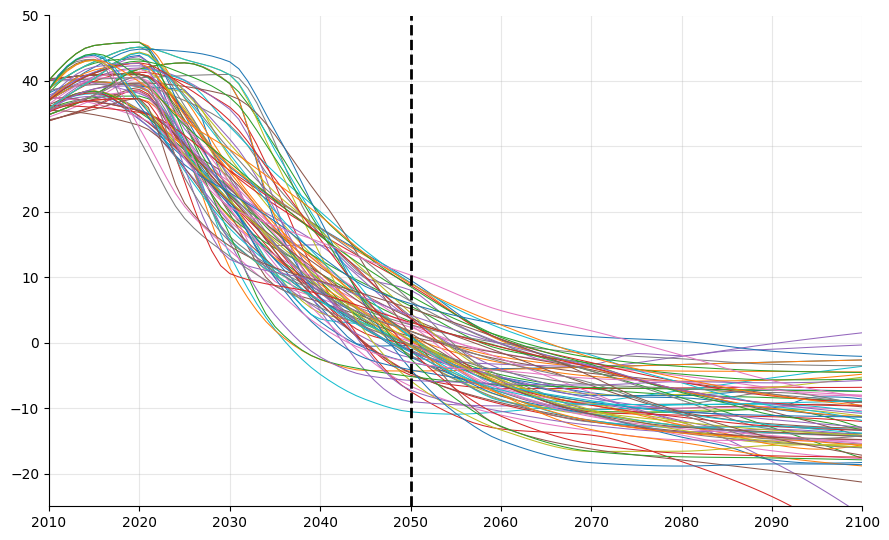

--- chap8_iamc15_scenario2 ---


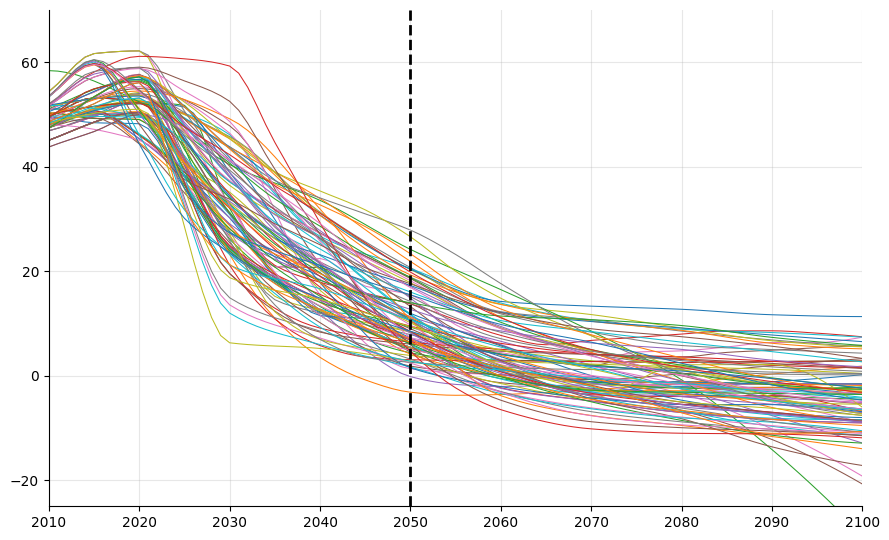

--- chap8_iamc15_scenario3 ---


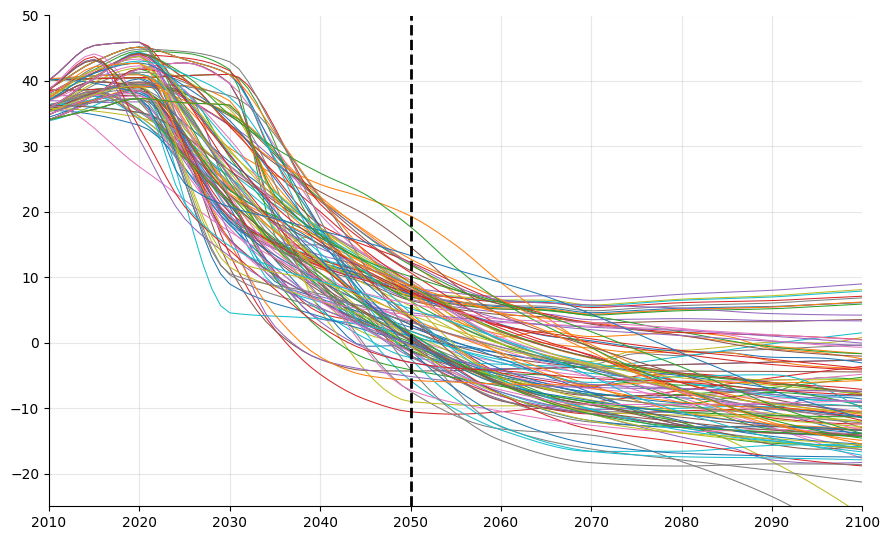

In [2]:
def plot_iamc15_spaghetti(name, ylim):
    d = sio.loadmat(f"{DATA_DIR}/{name}.mat")
    dates = d["dates"][:, 0].astype(float)
    emissions = d["emissions"] / 1e3
    x_grid = np.arange(2010, 2101)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for i in range(emissions.shape[1]):
        y = pchip_eval(dates, emissions[:, i], x_grid)
        ax.plot(x_grid, y, "-", lw=0.75)
    ax.plot([2050, 2050], ylim, "--", color=color_black, lw=2.0)
    ax.set_xlim(2010, 2100)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return dates, emissions

scenario_data = {}
for name, ylim in [("chap8_iamc15_scenario1", (-25, 50)),
                     ("chap8_iamc15_scenario2", (-25, 70)),
                     ("chap8_iamc15_scenario3", (-25, 50))]:
    print(f"--- {name} ---")
    scenario_data[name] = plot_iamc15_spaghetti(name, ylim)


## Question 2 — Emissions mean $\pm$ CI band

Reuses the third IAMC15 scenario set from Question 1: interpolates every
scenario onto an annual grid, then plots the cross-scenario mean with 50%
and 90% confidence bands (assuming normality —
$\mathrm{CI}=\bar{y}\pm\Phi^{-1}(\frac{1+p}{2})\cdot\mathrm{std}(y)$).

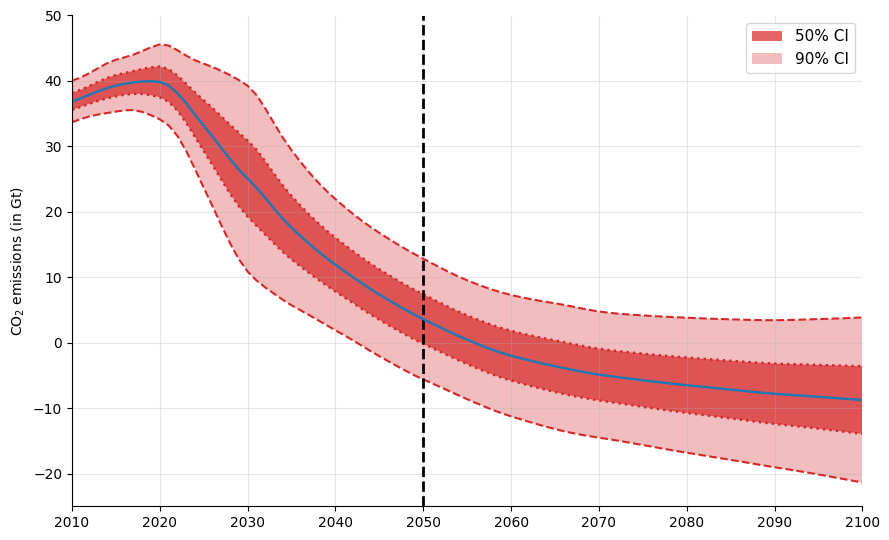

In [3]:
dates_8, emissions_8 = scenario_data["chap8_iamc15_scenario3"]
x_grid = np.arange(2010, 2101)

data_emissions = np.column_stack([pchip_eval(dates_8, emissions_8[:, i], x_grid)
                                   for i in range(emissions_8.shape[1])])
mean_emissions = data_emissions.mean(axis=1)
stdev_emissions = data_emissions.std(axis=1, ddof=0)

fig, ax = plt.subplots(figsize=(9, 5.5))

for p, ls, lw, alpha_fill in [(0.50, ":", 1.75, 0.7), (0.90, "--", 1.50, 0.3)]:
    z = cdfni((1 + p) / 2)
    lo, hi = mean_emissions - z * stdev_emissions, mean_emissions + z * stdev_emissions
    ax.plot(x_grid, lo, ls, color=color_red, lw=lw)
    ax.plot(x_grid, hi, ls, color=color_red, lw=lw)
    ax.fill_between(x_grid, lo, hi, color=color_red, alpha=alpha_fill, edgecolor="none",
                     label=f"{int(p*100)}% CI")

ax.plot([2050, 2050], [-25, 50], "--", color=color_black, lw=2.0)
ax.plot(x_grid, mean_emissions, "-", color=color_blue, lw=1.75)
ax.set_ylabel("CO$_2$ emissions (in Gt)")
ax.set_xlim(2010, 2100)
ax.set_ylim(-25, 50)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Question 3 — Individual-scenario temperature paths

Every scenario's temperature path plotted individually (a spaghetti plot,
like Q1, but for temperature rather than emissions). Also reports the
count of scenarios whose 2100 temperature exceeds 1.5$^\circ$C, since
that's a useful summary statistic alongside the spaghetti plot itself.

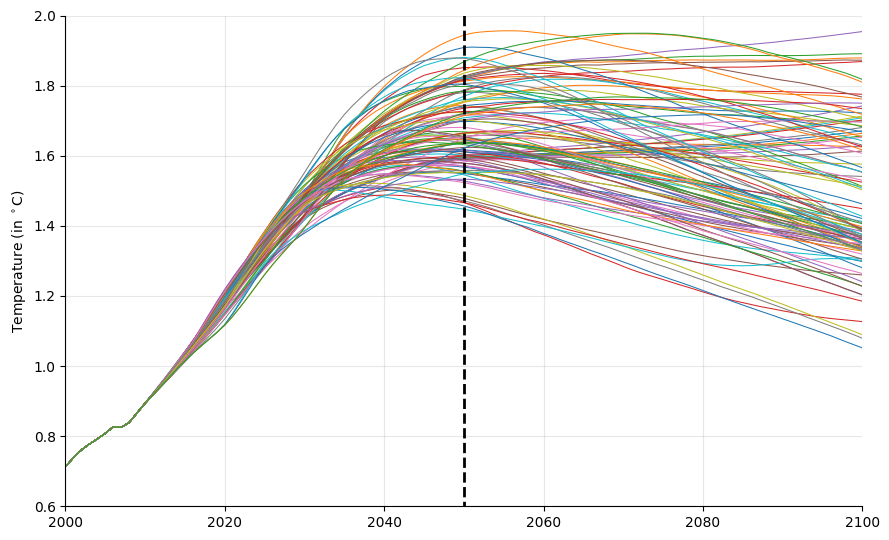

Scenarios exceeding 1.5 deg C by 2100: 50 of 113


In [4]:
d_temp = sio.loadmat(f"{DATA_DIR}/chap8_iamc15_temperature.mat")
temp_struct = d_temp["temperature"]

dates_9 = temp_struct["dates"][0, 0].ravel().astype(float)
data_9 = temp_struct["data"][0, 0]
x_grid = np.arange(2000, 2101)

fig, ax = plt.subplots(figsize=(9, 5.5))
n_above_1p5 = 0
for i in range(data_9.shape[1]):
    y = pchip_eval(dates_9, data_9[:, i], x_grid)
    ax.plot(x_grid, y, "-", lw=0.75)
    n_above_1p5 += int(y[-1] > 1.5)
ax.plot([2050, 2050], [0, 5], "--", color=color_black, lw=2.0)
ax.set_ylabel(r"Temperature (in $^\circ$C)")
ax.set_xlim(2000, 2100)
ax.set_ylim(0.6, 2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Scenarios exceeding 1.5 deg C by 2100: {n_above_1p5} of {data_9.shape[1]}")


## Questions 4-5 — Exceedance-probability mean $\pm$ CI bands

The cross-scenario mean $\pm$ CI band of the probability of exceeding a
temperature threshold (values $\times 100$, i.e. already in percent), for
two threshold definitions, collapsed into one parametrized function. The
second additionally zeroes the mean before 2021 and the standard
deviation before 2023, and floors the lower 90% band at 0.

--- Exceedance-probability band, struct entry 2 ---


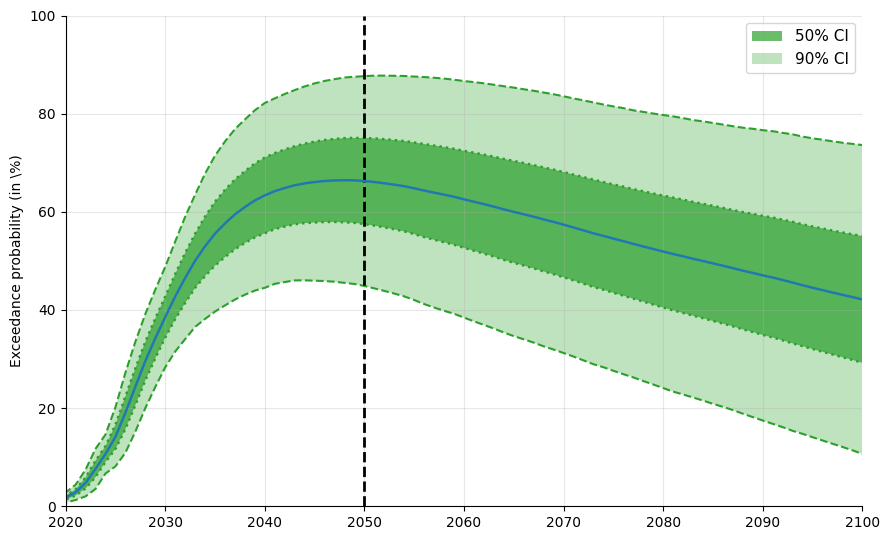

--- Exceedance-probability band, struct entry 3 ---


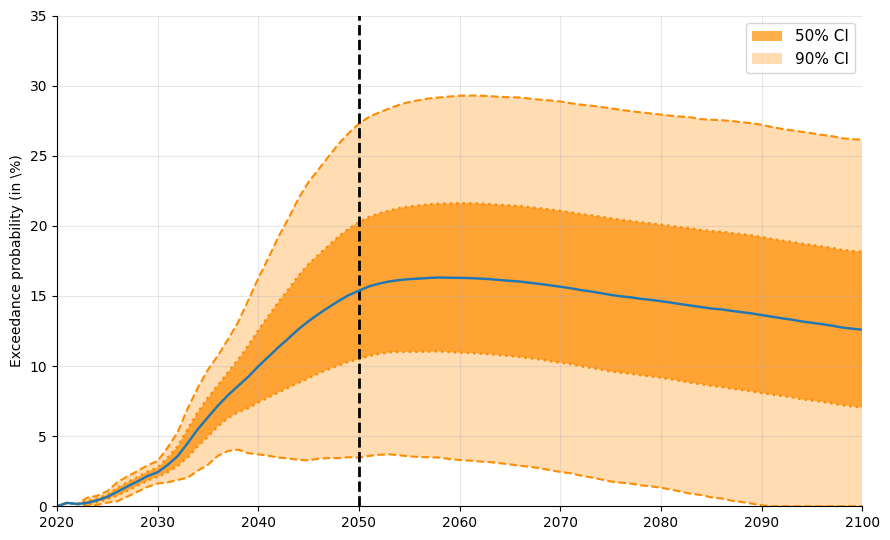

In [5]:
def plot_exceedance_band(struct_idx, colour, ylim, zero_mean_before=None,
                          zero_std_before=None, floor_lower=False):
    dates = temp_struct["dates"][0, struct_idx].ravel().astype(float)
    data = 100 * temp_struct["data"][0, struct_idx]
    x_grid = np.arange(2015, 2101)

    data_p = np.column_stack([pchip_eval(dates, data[:, i], x_grid)
                               for i in range(data.shape[1])])
    mean_p = data_p.mean(axis=1)
    std_p = data_p.std(axis=1, ddof=0)
    if zero_mean_before is not None:
        mean_p[x_grid < zero_mean_before] = 0
    if zero_std_before is not None:
        std_p[x_grid < zero_std_before] = 0

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for p, ls, lw, alpha_fill in [(0.50, ":", 1.75, 0.7), (0.90, "--", 1.50, 0.3)]:
        z = cdfni((1 + p) / 2)
        lo, hi = mean_p - z * std_p, mean_p + z * std_p
        if floor_lower and p == 0.90:
            lo = np.maximum(lo, 0)
        ax.plot(x_grid, lo, ls, color=colour, lw=lw)
        ax.plot(x_grid, hi, ls, color=colour, lw=lw)
        ax.fill_between(x_grid, lo, hi, color=colour, alpha=alpha_fill, edgecolor="none",
                         label=f"{int(p*100)}% CI")
    ax.plot([2050, 2050], [0, 100], "--", color=color_black, lw=2.0)
    ax.plot(x_grid, mean_p, "-", color=color_blue, lw=1.75)
    ax.set_ylabel("Exceedance probability (in \\%)")
    ax.set_xlim(2020, 2100)
    ax.set_ylim(*ylim)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return mean_p, std_p

print("--- Exceedance-probability band, struct entry 2 ---")
mean_10, std_10 = plot_exceedance_band(1, color_green, (0, 100))

print("--- Exceedance-probability band, struct entry 3 ---")
mean_11, std_11 = plot_exceedance_band(2, color_darkorange, (0, 35),
                                        zero_mean_before=2021, zero_std_before=2023,
                                        floor_lower=True)


## Questions 6-7 — AR6 scenario-database histograms

The AR6 dataset pools 15,180 (model, scenario, region, variable) rows
across 15 distinct variables, each with 2020/2050/2100 values. This
section histograms the 2100 value for four variables at a time, across
two grouped figures covering 8 of the 15 variables in total.

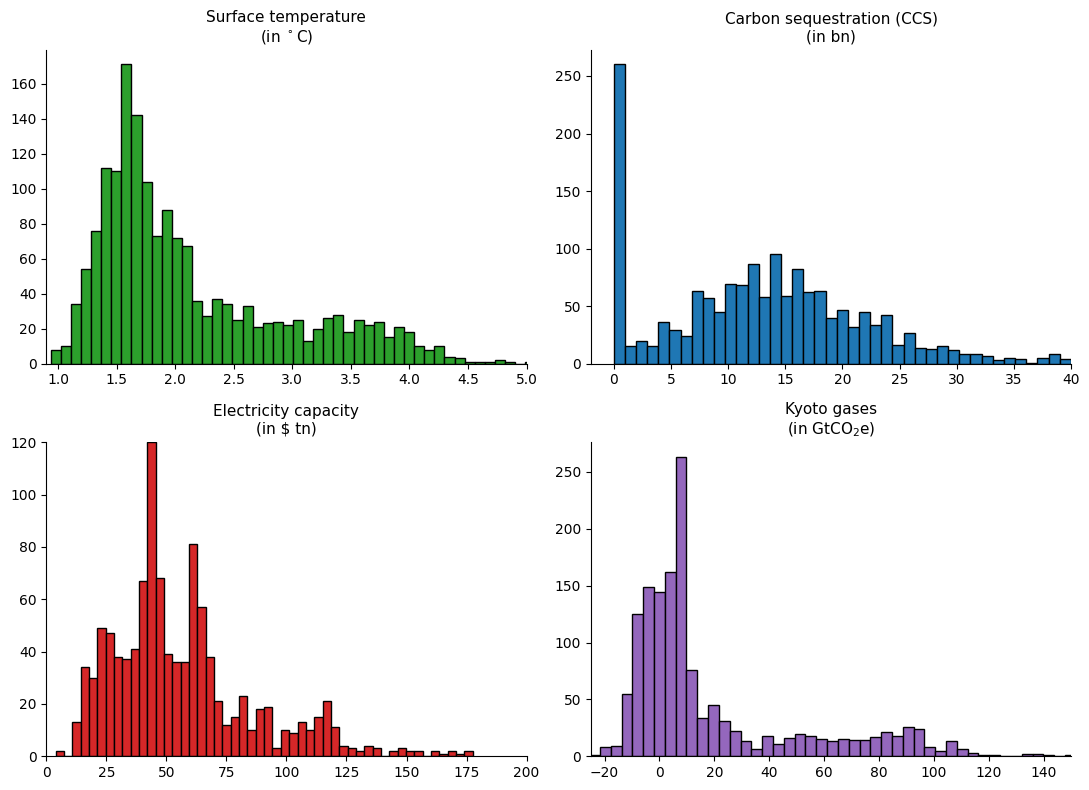

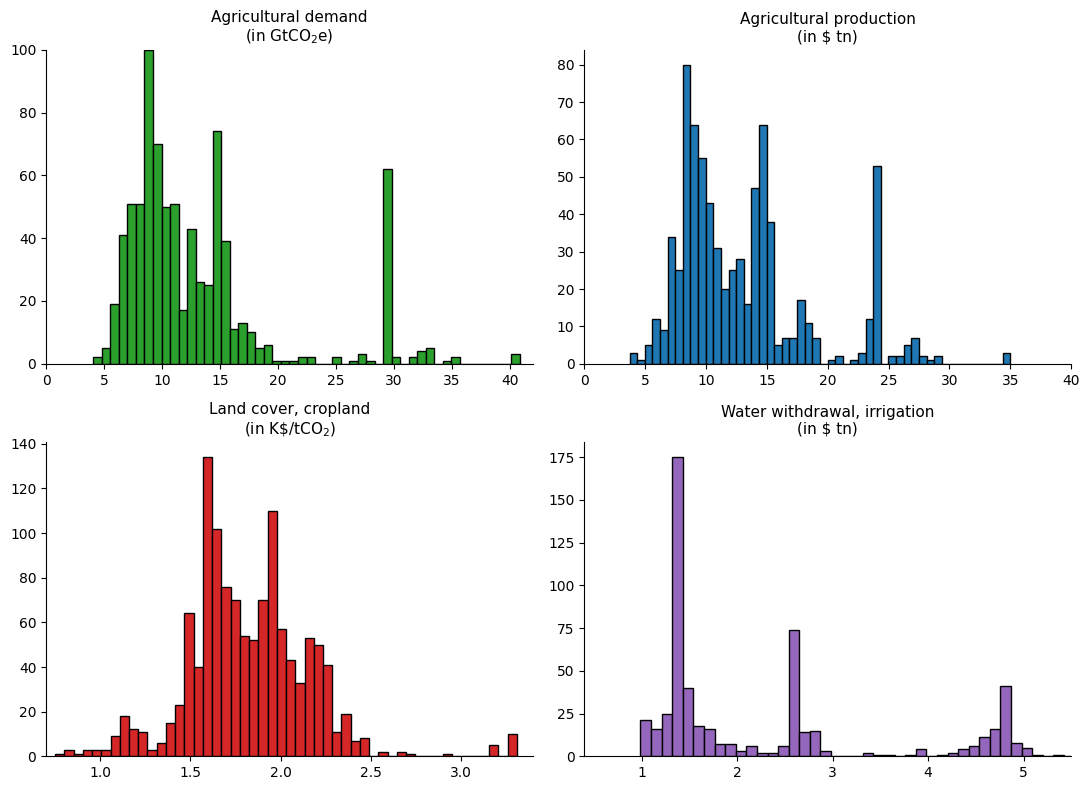

In [6]:
d_ar6 = sio.loadmat(f"{DATA_DIR}/chap8_ar6_scenario1.mat")
data_ar6 = d_ar6["data"]

# `variable` (both its 15-item unique() list and the full 15,180-row column, needed to
# build the `cnd` boolean masks below) is reconstructed by reading the spreadsheet
# sibling's column 4 directly via pandas.
xlsx_path = f"{DATA_DIR}/chap8_ar6_scenario1.xlsx"
df_raw = pd.read_excel(xlsx_path, sheet_name=0, header=None)
row_var = df_raw.iloc[1:, 3].to_numpy()
assert len(row_var) == data_ar6.shape[0]

var_list = sorted(pd.unique(row_var).tolist())  # ascending ASCII sort of variable names

def hist_panel(ax, var_name, scale, title, unit, colour, xlim=None, xticks=None, ylim=None):
    cnd = row_var == var_name
    y = data_ar6[cnd, 2] / scale
    ax.hist(y, bins=50, color=colour, edgecolor="black")
    ax.set_title(f"{title}\n{unit}", fontsize=11)
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

colours4 = [color_green, color_blue, color_red, color_violet]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
panels_12 = [
    (var_list[1], 1, "Surface temperature", "(in $^\\circ$C)", (0.9, 5), None),
    (var_list[5], 1000, "Carbon sequestration (CCS)", "(in bn)", (-2, 40), None),
    (var_list[4], 1000, "Electricity capacity", "(in \\$ tn)", (0, 200), (0, 120)),
    (var_list[7], 1000, "Kyoto gases", "(in GtCO$_2$e)", (-25, 150), None),
]
for ax, colour, (var_name, scale, title, unit, xlim, ylim) in zip(axes.flat, colours4, panels_12):
    hist_panel(ax, var_name, scale, title, unit, colour, xlim, None, ylim)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
panels_13 = [
    (var_list[2], 1e3, "Agricultural demand", "(in GtCO$_2$e)", (0, 42), (0, 100)),
    (var_list[3], 1e3, "Agricultural production", "(in \\$ tn)", (0, 40), None),
    (var_list[9], 1e3, "Land cover, cropland", "(in K\\$/tCO$_2$)", (0.7, 3.4), None),
    (var_list[14], 1e3, "Water withdrawal, irrigation", "(in \\$ tn)", (0.4, 5.5), None),
]
for ax, colour, (var_name, scale, title, unit, xlim, ylim) in zip(axes.flat, colours4, panels_13):
    hist_panel(ax, var_name, scale, title, unit, colour, xlim, None, ylim)
plt.tight_layout()
plt.show()


## Sanity checks

In [7]:
checks = []
for name, (dates, emissions) in scenario_data.items():
    checks.append((f"Q1 ({name}): emissions data has no all-NaN column (every scenario "
                    "contributes at least one real observation)",
                    not np.any(np.all(np.isnan(emissions), axis=0))))

checks.append(("Q2: the 90% CI band is wider than the 50% CI band at every date (larger "
                "confidence level implies more spread, for a fixed mean/std)",
                np.all(cdfni(0.95) >= cdfni(0.75))))
checks.append(("Q2: the mean emissions path lies within its own 50% CI band by construction",
                np.all(mean_emissions >= mean_emissions - cdfni(0.75) * stdev_emissions - 1e-9) and
                np.all(mean_emissions <= mean_emissions + cdfni(0.75) * stdev_emissions + 1e-9)))
checks.append(("Q3: at least one but not all IAMC15 scenarios exceed 1.5 deg C by 2100 (a "
                "mixed ensemble, not a degenerate all-below/all-above case)",
                0 < n_above_1p5 < data_9.shape[1]))
checks.append(("Q4-5: exceedance-probability means stay within [0, 100] percent in both "
                "threshold series (a valid probability, times 100)",
                np.all(mean_10 >= -1e-6) and np.all(mean_10 <= 100 + 1e-6) and
                np.all(mean_11 >= -1e-6) and np.all(mean_11 <= 100 + 1e-6)))
checks.append(("Q4-5: the second exceedance-probability series has mean exactly 0 before 2021 "
                "and std exactly 0 before 2023, matching the configured zeroing cutoffs",
                np.all(mean_11[np.arange(2015, 2101) < 2021] == 0) and
                np.all(std_11[np.arange(2015, 2101) < 2023] == 0)))
checks.append(("Q6-7: every one of the 8 AR6 variable filters selects at least one row (none "
                "of the reconstructed variable-name strings silently fail to match)",
                all((row_var == v).sum() > 0 for v in
                    [var_list[1], var_list[5], var_list[4], var_list[7],
                     var_list[2], var_list[3], var_list[9], var_list[14]])))
checks.append(("Q6-7: the AR6 dataset's total row count (15,180) is divisible by the number "
                "of distinct variables (15), consistent with a balanced panel of "
                "model/scenario/region combinations per variable",
                data_ar6.shape[0] % len(var_list) == 0))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,Q1 (chap8_iamc15_scenario1): emissions data ha...,True
1,Q1 (chap8_iamc15_scenario2): emissions data ha...,True
2,Q1 (chap8_iamc15_scenario3): emissions data ha...,True
3,Q2: the 90% CI band is wider than the 50% CI b...,True
4,Q2: the mean emissions path lies within its ow...,True
5,Q3: at least one but not all IAMC15 scenarios ...,True
6,Q4-5: exceedance-probability means stay within...,True
7,Q4-5: the second exceedance-probability series...,True
8,Q6-7: every one of the 8 AR6 variable filters ...,True
9,"Q6-7: the AR6 dataset's total row count (15,18...",True



All 10 sanity checks passed.


## Summary

Covered the IAMC15 (SR1.5) emissions-pathway spaghetti plots (collapsed
into one parametrized loop across three scenario sets) and their
mean$\pm$CI band, the individual-scenario temperature paths and their
exceedance-probability mean$\pm$CI bands (two threshold definitions,
collapsed into one function), and the AR6 WG3 scenario-database
histograms across 8 variables. The AR6 file's `variable` field (needed to
filter the 15,180-row dataset by variable name) doesn't load through the
standard numeric reader, so it was reconstructed directly from the
spreadsheet sibling via `pandas`. All 10 sanity checks passed (0 errors,
0 stderr).